# Pre-class Assignment 5

**Due Tuesday night of Week 5**

#### &#9989; Owen Sliger

---

## Precise Approximation

In this PCA, we introduce a precise approximation that can be applied across any function or curve you can think of. This approximation is a series sum, and it will become more and more precise as you increase the number of terms included.
 Below, a generalized implementation of this new approximation is written in code.

**&#9989; Do this:** Review the code below, and **write a formula** for this series sum.

$$\frac{1}{2}(\sum_{n=0}^{a}a_n-ib_ne^{\frac{i2\pi nx}{L}} + \sum_{n=0}^{a}a_n+ib_ne^{\frac{-i2\pi nx}{L}})$$

In [1]:
import numpy as np

# given terms
a = [25.37, 4.16, -2.24, 4.48, -2.07, 3.04, 1.56, -1.22, 1.33, -1.09]
b = [0, -5.95, -2.11, 0.19, -2.09, -0.67, 1.78, 1.13, 0.16, -0.06]

# independent variable
L = 40
x_vals = np.linspace(0, L, 1000)

# series approximation
y_vals = np.zeros(len(x_vals), dtype="complex")

N = len(a)

for n in range(N):
    theta = 2 * np.pi * x_vals / L
    c_pos_term = 0.5 * (a[n] - 1j * b[n]) * np.exp(1j * n * theta)
    c_neg_term = 0.5 * (a[n] + 1j * b[n]) * np.exp(-1j * n * theta)
    y_vals += c_pos_term + c_neg_term

You may have seen Fourier Series introduced in Oscillation and Waves like this: https://books.physics.oregonstate.edu/GMM/fourieroverview.html.

Written here:

$$f(\theta) = \frac{1}{2}a_0 + \sum_{n=1}^{\infty} a_n \cos\left(n\theta\right) + b_n \sin\left(n\theta\right) $$

We can take advantage of the Euler identity, $e^{i\theta} = \cos\theta + i\sin\theta$.

If we define a new term, 

$$c_n := \begin{cases} 
          \frac{1}{2} \left( a_n - ib_n \right) & n \ge 0 \\
          \frac{1}{2} \left( a_{-n} + ib_{-n} \right) & n < 0
       \end{cases}$$
       
then we can simplify our series sum. Here, we work backwards to get there:

$$\begin{align}
c_{n}e^{in\theta} + c_{-n}e^{-in\theta} &= \frac{1}{2}(a_n - ib_n)(\cos(n\theta) + i \sin(n\theta)) + \frac{1}{2}(a_n + ib_n)(\cos(n\theta) - i \sin(n\theta)) \\
&= \frac{1}{2} \left(a_n\cos + ia_n\sin - ib_n\cos + b_n\sin + a_n\cos - ia_n\sin + ib_n\cos + b_n\sin \right) \\
&= a_n\cos(n\theta) + b_n\sin(n\theta)
\end{align}$$

When we make this substition in the series, we get:

$$f(\theta) = \sum_{n=-\infty}^{\infty} c_n e^{in\theta}$$

**&#9989; Do this:** Identify the differences between your answer to the previous task, and this simplified version of Fourier series with the $c_n$ terms.

The bounds of the sum have changed from some a length, to negative and positive infinity. There is also no addition of sums. In the Euler form, both positive and negative portions of the sums are combined in the imaginary parts of the new function

One difference you should have identified is the difference in the limit of the sum. Going to $N$ vs going to $\infty$. We can't go to infinity when we use computing, so we *approximate* by going to $N$, which should be a large enough number to capture all the biggest terms in the sum.

The `a` and `b` arrays above are given terms corresponding to a mystery function, which your will approximate as a way to explore using **Fourier series** as a computational tool.

**&#9989; Do this:** Plot multiple approximations of the mystery function (defined over x = 0 to 40) to see the increasing precision. Plot the approximations corresponding to $N = 1,2,4,9$.

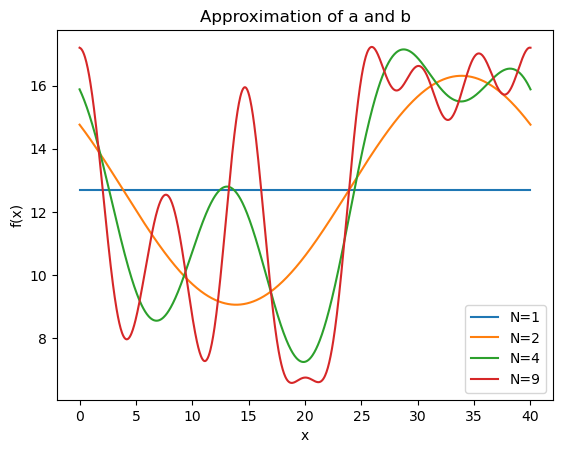

In [2]:
import matplotlib.pyplot as plt
import numpy as np

N1 = 1 ; N2 = 2 ; N3 = 4 ; N4 = 9
f1 = 0 ; f2 = 0 ; f3 = 0 ; f4 = 0

a = [25.37, 4.16, -2.24, 4.48, -2.07, 3.04, 1.56, -1.22, 1.33, -1.09]
b = [0, -5.95, -2.11, 0.19, -2.09, -0.67, 1.78, 1.13, 0.16, -0.06]

L = 40
x_vals = np.linspace(0, L, 1000)
theta = 2 * np.pi * x_vals / L

for i in range(N1):
    f1 += 0.5*(a[i]-1j*b[i])*np.exp(1j*i*theta)
    
for i in range(N2):
    f2 += 0.5*(a[i]-1j*b[i])*np.exp(1j*i*theta)
    
for i in range(N3):
    f3 += 0.5*(a[i]-1j*b[i])*np.exp(1j*i*theta)

for i in range(N4):
    f4 += 0.5*(a[i]-1j*b[i])*np.exp(1j*i*theta)
    
plt.plot(x_vals,f1.real,label='N=1');
plt.plot(x_vals,f2.real,label='N=2');
plt.plot(x_vals,f3.real,label='N=4');
plt.plot(x_vals,f4.real,label='N=9');
plt.title('Approximation of a and b')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend();

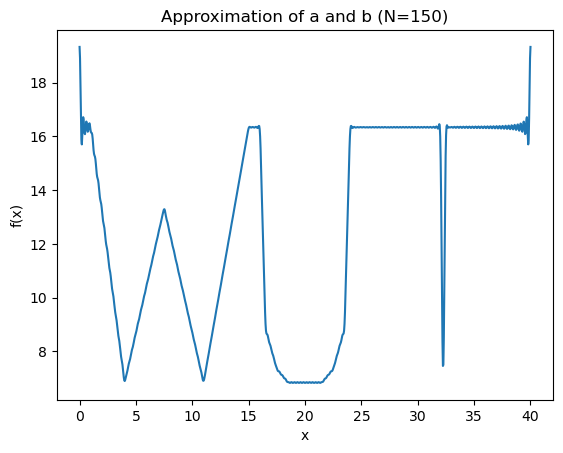

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/home/hub_data_share/data/ab.csv',delimiter = ',')
a = df['an'].to_numpy()
b = df['bn'].to_numpy()

L = 40
N = 150
f = 0

x_vals = np.linspace(0, L, 1000)
theta = 2 * np.pi * x_vals / L

for i in range(N):
    f += 0.5*(a[i]-1j*b[i])*np.exp(1j*i*theta)

plt.plot(x_vals,f.real);
plt.title('Approximation of a and b (N=150)')
plt.xlabel('x')
plt.ylabel('f(x)');

---

## Adding Precision

There are many more terms that were not included in the original `a` and `b` arrays. They can be found in `~/hub_data_share/data/ab.csv`

Watch the video below for a short walkthrough of using data sets in the JupyterHub environment.

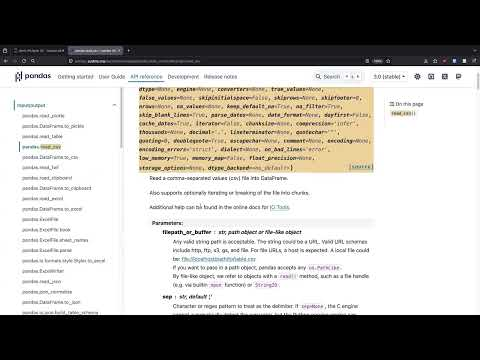

In [4]:
from IPython.display import YouTubeVideo
YouTubeVideo("tlNyWTIk0As", width=800, height=450)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_ymlqm77j

**&#9989; Do this:** Load the `ab.csv` data set as a pandas DataFrame **and** display it.

In [5]:
import pandas as pd
import pandas as pd

df = pd.read_csv('/home/hub_data_share/data/ab.csv')

df

,n,an,bn
0,0,25.365018,0.000000
1,1,4.162085,-5.953155
2,2,-2.237163,-2.107747
3,3,4.480796,0.188233
4,4,-2.065716,-2.093477
...,...,...,...
145,145,0.042088,0.002336
146,146,0.034617,0.001108
147,147,0.046935,0.000102
148,148,0.036573,-0.000658


**&#9989; Do this:** Create two new columns in the DataFrame, one for $c_n$ and one for $c_{-n}$.

In [6]:
df['cn'] = 0.5*(df['an']-1j*df['bn'])
df['c-n'] = 0.5*(df['an']+1j*df['bn'])

df

,n,an,bn,cn,c-n
0,0,25.365018,0.000000,12.682509+ 0.000000j,12.682509+ 0.000000j
1,1,4.162085,-5.953155,2.081043+ 2.976577j,2.081043- 2.976577j
2,2,-2.237163,-2.107747,-1.118581+ 1.053873j,-1.118581- 1.053873j
3,3,4.480796,0.188233,2.240398- 0.094117j,2.240398+ 0.094117j
4,4,-2.065716,-2.093477,-1.032858+ 1.046739j,-1.032858- 1.046739j
...,...,...,...,...,...
145,145,0.042088,0.002336,0.021044- 0.001168j,0.021044+ 0.001168j
146,146,0.034617,0.001108,0.017308- 0.000554j,0.017308+ 0.000554j
147,147,0.046935,0.000102,0.023468- 0.000051j,0.023468+ 0.000051j
148,148,0.036573,-0.000658,0.018287+ 0.000329j,0.018287- 0.000329j


**&#9989; Do this:** Apply Fourier series using your updated list of coefficients to compute and plot the most precise possible series approximation of the mystery function.

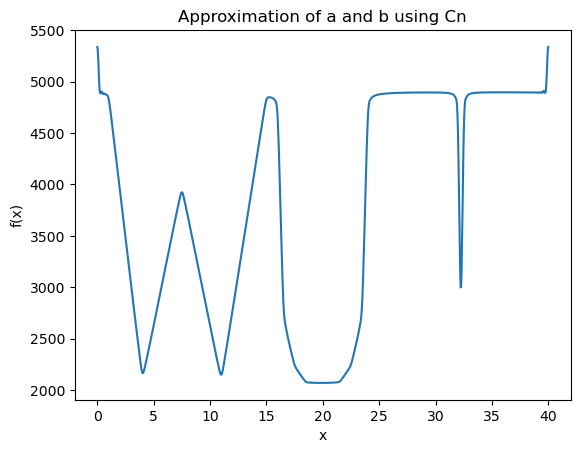

In [7]:
cn = np.array(df['cn'])
c_n = np.array(df['c-n'])

L = 40
f = 0

x_vals = np.linspace(0, L, 1000)
theta = 2 * np.pi * x_vals / L
N = cn.size
c_pos = 0 ; c_neg = 0
f = np.zeros(len(x_vals), dtype="complex")

for i in range(N):
    c_pos += cn[i]*np.exp(1j*i*theta)
    c_neg += c_n[i]*np.exp(-1*1j*i*theta)
    
    f += c_pos + c_neg
        

plt.plot(x_vals,f.real);
plt.title('Approximation of a and b using Cn')
plt.xlabel('x')
plt.ylabel('f(x)');

*For more on Fourier series, this is a helpful conceptual video: https://www.youtube.com/watch?v=r6sGWTCMz2k.*

### That's all! You've reached the end of the pre-class assignment.

Scroll through to make sure you didn't miss any tasks (marked with &#x2705;). Download your work as an HTML file, by selecting: `File` --> `Save and Export Notebook As...` --> `HTML` inside the JupyterHub interface (don't select your browser's File menu). 

Open your downloaded file to ensure the contents look okay, then submit it on Canvas.